# 05 · Bulletin 17C examples 2 and 4

Use the original Orestimba Creek and Arkansas River at Pueblo inputs to understand low floods, historical intervals and nonexceedance information.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Example 2: Orestimba Creek, California
USGS station 11274500 has 82 annual peaks for 1932–2013 in this reference example, including 12 zeros.
The saved app input flags 30 low floods at a 782 cfs threshold. Keep the original observations and flags together.
The newer download in notebook 01 contains a longer record and is a different analysis.

The official Bulletin 17C workflow uses EMA and MGBT. These notebooks show BestFit's GMM implementation and its saved MVN/BCB uncertainty alternatives.
A GMM uncertainty ensemble is not a Bayesian posterior chain, and its intervals are confidence intervals.

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
1,Example #2 - Data,Peak Flow (cfs),Manual,82,0,0,0,30
3,Example #4 - Data,Peak Flow (cfs),Manual,81,0,4,4,0


,Alternative,Uncertainty method,Ensemble output length,Interval width,PRNG seed,Compatibility container
0,Example #2,MultivariateNormal,10000,0.9,12345,DEMCzs (inactive sampler for B17C)
1,Example #2 - BCB,BiasCorrectedBootstrap,1000,0.9,12345,DEMCzs (inactive sampler for B17C)
2,Example #4,LinkedMultivariateNormal,10000,0.9,12345,DEMCzs (inactive sampler for B17C)
3,Example #4 - BCB,BiasCorrectedBootstrap,1000,0.9,12345,DEMCzs (inactive sampler for B17C)


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Example #2,saved-app,sha256:2e55826d0492,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,Example #2 - BCB,saved-app,sha256:2e55826d0492,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,Example #4,saved-app,sha256:2e55826d0492,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
3,Example #4 - BCB,saved-app,sha256:2e55826d0492,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


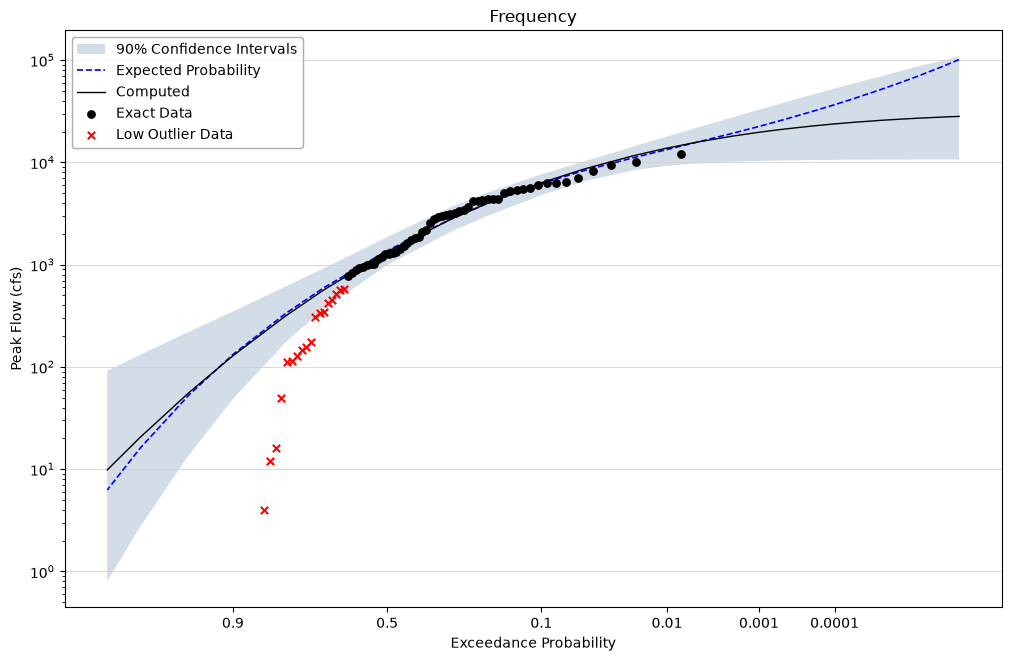

,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Mean (of log) (µ),3.022663,False,1.110223e-16,4.0,Numerics.Distributions.Uniform
1,Std Dev (of log) (σ),0.682087,False,1.110223e-16,3.0,Numerics.Distributions.Uniform
2,Skew (of log) (γ),-0.929110,False,-6.000000e+00,6.0,Numerics.Distributions.Uniform


,AEP,Expected Probability,Computed
0,0.500,1369.038883,1339.142563
1,0.100,6225.727309,6328.297873
2,0.010,13382.516162,13823.814991
3,0.002,19365.760577,18149.723003
4,0.001,22498.625934,19726.192651


In [2]:
PROJECT = "bulletin-17c-examples"
project = load_project(PROJECT)
display(input_inventory(project).query("Input in ['Example #2 - Data', 'Example #4 - Data']"))
names = ["Example #2", "Example #2 - BCB", "Example #4", "Example #4 - BCB"]
cases = {name:saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names}
display(pd.DataFrame([{
    "Alternative": name,
    "Uncertainty method": case.data["settings"]["UncertaintyMethod"],
    "Ensemble output length": int(case.data["settings"]["BayesianAnalysis.OutputLength"]),
    "Interval width": float(case.data["settings"]["BayesianAnalysis.CredibleIntervalWidth"]),
    "PRNG seed": int(case.data["settings"]["BayesianAnalysis.PRNGSeed"]),
    "Compatibility container": case.data["settings"]["BayesianAnalysis.Type"] + " (inactive sampler for B17C)",
} for name, case in cases.items()]))
display(case_provenance(list(cases.values())))
cases["Example #2"].show("frequency")
display(cases["Example #2"].parameters)
display(cases["Example #2"].frequency_table())

## Example 4: Arkansas River at Pueblo, Colorado
USGS station 07099500 combines 81 exact peaks, four event intervals and four perception-threshold records.
The long nonexceedance information reaches back to 1165. It is represented by explicit windows, not invented annual values.
The MVN alternative uses the saved linked-multivariate-normal setting; the BCB alternative retains its original bootstrap configuration.

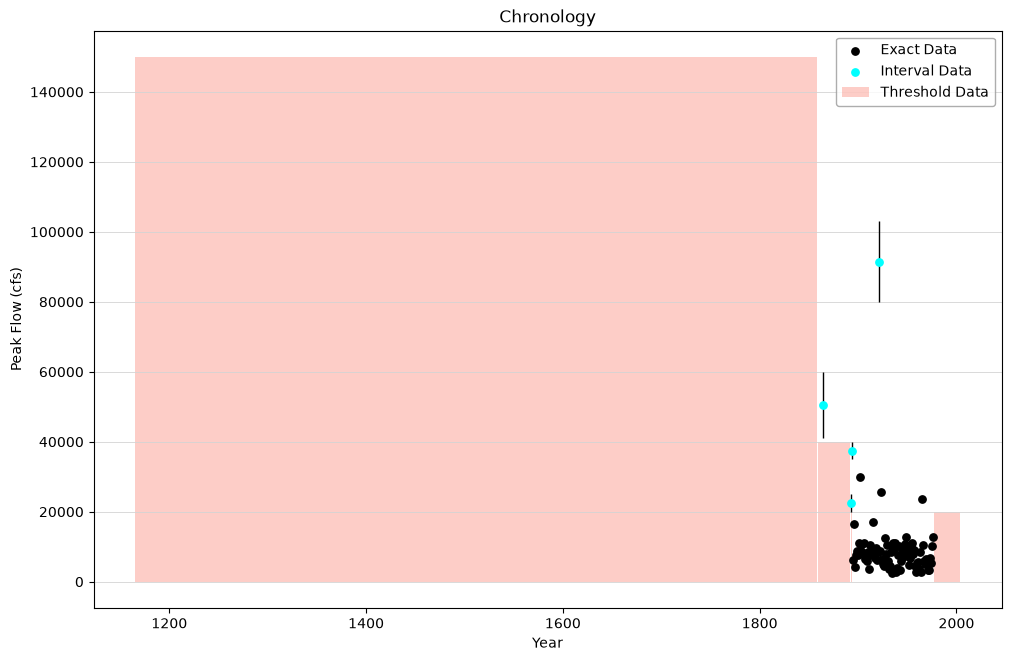

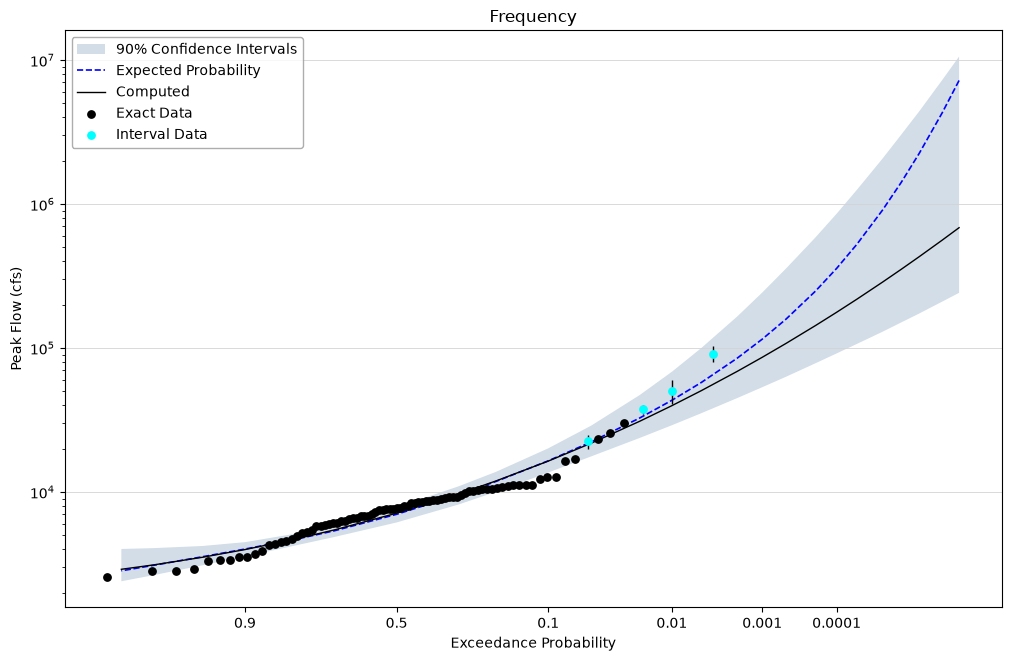

,Setting,Saved choice
0,Analysis,Bulletin17CAnalysis
1,InputData,Example #4 - Data
2,UncertaintyMethod,LinkedMultivariateNormal
3,BayesianAnalysis.Type,DEMCzs
4,BayesianAnalysis.NumberOfChains,4
5,BayesianAnalysis.ThinningInterval,20
6,BayesianAnalysis.WarmupIterations,1500
7,BayesianAnalysis.Iterations,3000
8,BayesianAnalysis.UseSimulationDefaults,True
9,BayesianAnalysis.PRNGSeed,12345


In [3]:
historical = saved_case(PROJECT, "Example #4 - Data", table="Input Data")
historical.show("chronology")
cases["Example #4"].show("frequency")
display(cases["Example #4"].settings)

## Reference comparison and interpretation
Appendix 10 describes Orestimba starting on printed page 111 and Pueblo on page 123.
Tables 10-9 and 10-17 report 13,820 cfs for Orestimba and 39,800 cfs for Pueblo at 1% AEP. Compare the computed curve and the method-specific intervals separately;
agreement after published rounding is a different check from uncertainty-interval agreement. The official examples use station skew.

Reference: [England et al., Bulletin 17C, version 1.1 (May 2019), Appendix 10](https://pubs.usgs.gov/tm/04/b05/tm4b5.pdf).

,Station,Table,Published EMA (cfs),Saved GMM (cfs),Difference (%)
0,"Orestimba Creek near Newman, California",10-9,13820,13823.814991,0.027605
1,"Arkansas River at Pueblo, Colorado",10-17,39800,39780.299176,-0.049500


,AEP,Expected Probability,Computed,Alternative
0,0.01,13382.516162,13823.814991,Example #2
1,0.01,12890.257290,13823.814991,Example #2 - BCB
2,0.01,43357.517831,39780.299176,Example #4
3,0.01,44145.087249,39780.299176,Example #4 - BCB


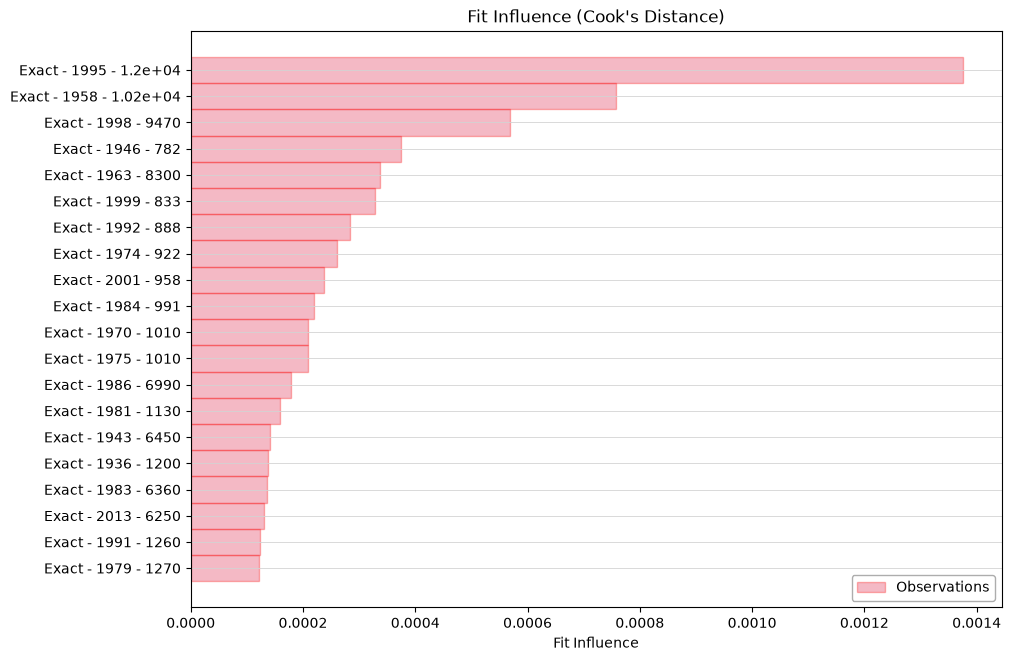

In [4]:
checks = json.loads((ROOT / "validation/source-checks.json").read_text(encoding="utf-8"))
display(pd.DataFrame([{ "Station": entry["station"], "Table": entry["published_table"],
                       "Published EMA (cfs)": entry["published_ema_cfs"], "Saved GMM (cfs)": entry["saved_gmm_cfs"],
                       "Difference (%)": entry["difference_percent_of_published"] }
                      for entry in checks["bulletin_17c"].values()]))
display(pd.concat([case.frequency_table((.01,)).assign(Alternative=name) for name,case in cases.items()], ignore_index=True))
cases["Example #2"].show("diagnostic_influence")